Загрузка данных...
Количество отзывов: 63

Первые строки датасета:


,Источник,Продукт,Оценка,Отзыв
0,IRecommend,Крем для лица Гельтек Ночной увлажняющий,4.7,"Максимально нейтральный, но при этом эффективн..."
1,IRecommend,Крем для лица Гельтек Ночной увлажняющий,4.0,Этот крем с увлажнением кожи в осенне-зимний п...
2,IRecommend,Крем для лица Гельтек Ночной увлажняющий,5.0,Хороший вариант крема на лето для всех типов кожи
3,IRecommend,Крем для лица Гельтек Ночной увлажняющий,3.0,"Плюсы: Крем легкий, текстура приятная, не липк..."
4,IRecommend,Крем для лица Гельтек Ночной увлажняющий,5.0,Мне этот крем очень полюбился! Крем очень хоро...



Предобработка текста...

Пример очистки текста:


,Отзыв,clean_review
0,"Максимально нейтральный, но при этом эффективн...",максимально нейтральный эффективный приятный у...
1,Этот крем с увлажнением кожи в осенне-зимний п...,крем увлажнением кожи осенне зимний период вкл...
2,Хороший вариант крема на лето для всех типов кожи,хороший вариант крема лето типов кожи
3,"Плюсы: Крем легкий, текстура приятная, не липк...",плюсы крем легкий текстура приятная липкая зап...
4,Мне этот крем очень полюбился! Крем очень хоро...,крем очень полюбился крем очень выполняет свои...



Анализ тональности...

Распределение тональности:
Тональность
Положительный    46
Нейтральный       9
Негативный        8
Name: count, dtype: int64

Процентное распределение:
Тональность
Положительный    73.0
Нейтральный      14.3
Негативный       12.7
Name: count, dtype: float64


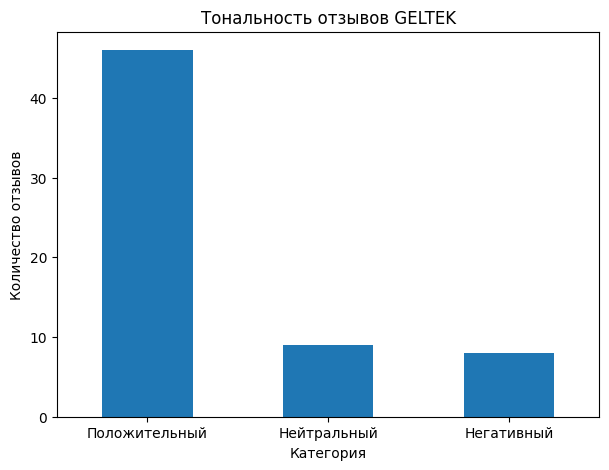


Отзывы по источникам:
Источник
IRecommend                 21
Официальный сайт GELTEK    21
Wildberries                21
Name: count, dtype: int64


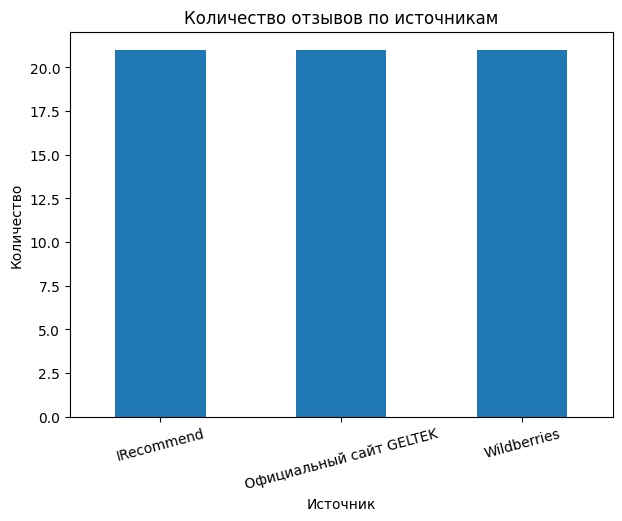


Построение облака слов...


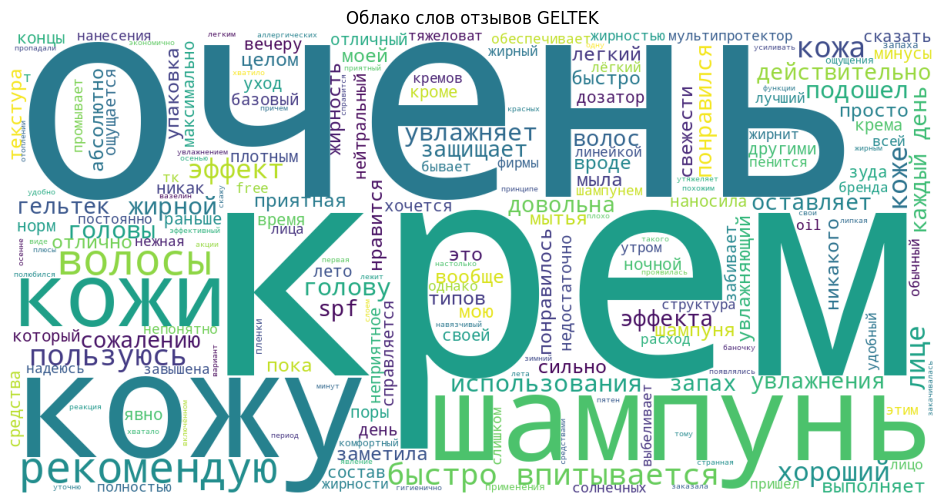


ТОП-20 слов:


,Слово,Количество
0,крем,30
1,очень,26
2,кожу,12
3,шампунь,12
4,кожи,11
5,быстро,11
6,впитывается,9
7,рекомендую,8
8,волосы,8
9,пользуюсь,7


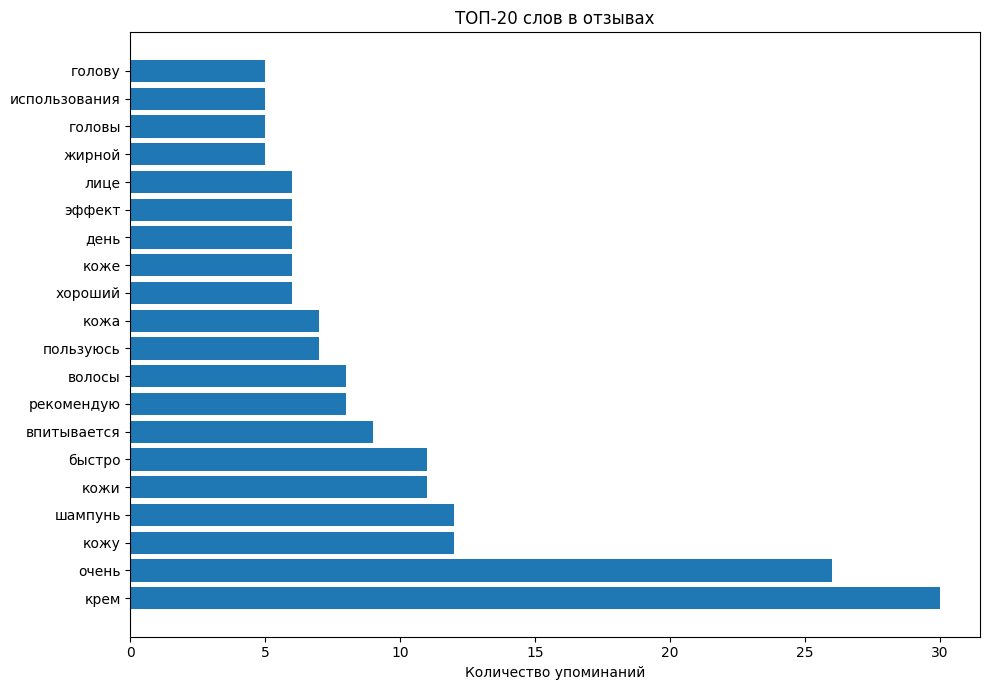


Тематический анализ...

Основные темы:


,Тема,Количество
0,Качество,14
1,Увлажнение,10
2,Цена,2
3,Упаковка,5
4,Доставка,1
5,Кожа,7


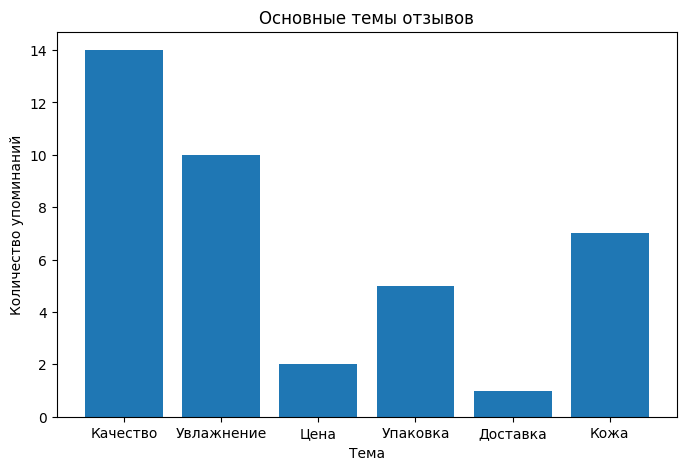


Проверка качества анализа...
Для проекта проведена ручная проверка 10 случайных отзывов.
Автоматическая классификация сопоставлялась с пользовательскими оценками.


,Оценка,Тональность,Отзыв
61,3.0,Нейтральный,"Лицо после нанесения блести, кроме того, остав..."
57,5.0,Положительный,"Все понравилось: впитывается быстро, не выбели..."
0,4.7,Положительный,"Максимально нейтральный, но при этом эффективн..."
43,5.0,Положительный,"Крем пришел целый, не вскрытый, срок годности ..."
5,5.0,Положительный,"Отличный базовый крем, который не конфликтует ..."
36,5.0,Положительный,"Сам кремушек очень понравился,легко наносится,..."
16,2.0,Негативный,"После нанесения, спустя небольшой промежуток в..."
12,4.0,Положительный,Шампунь Гельтек можно назвать хорошим продукто...
25,3.0,Нейтральный,"К сожалению, крем мне вообще не подошел, очень..."
60,5.0,Положительный,"Не жирнит кожу, не ощущается на лице, все понр..."



ИТОГОВЫЕ ВЫВОДЫ
Положительные отзывы: 73.0%
Нейтральные отзывы: 14.3%
Негативные отзывы: 12.7%

Наиболее обсуждаемые темы:


,Тема,Количество
0,Качество,14
1,Увлажнение,10
5,Кожа,7
3,Упаковка,5
2,Цена,2
4,Доставка,1



Основные сильные стороны бренда:
- качество продукции
- эффективность средств

Проблемные зоны:
- цена
- упаковка
- доставка

Файл geltek_analysis_results.xlsx сохранен.

Проект успешно выполнен!


In [3]:
# ИТОГОВЫЙ ПРОЕКТ
# АНАЛИЗ ОТЗЫВОВ О БРЕНДЕ GELTEK

!pip install -q pandas openpyxl nltk wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import re

from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud

print("Загрузка данных...")

df = pd.read_excel("reviews_geltek.xlsx")

print(f"Количество отзывов: {len(df)}")

print("\nПервые строки датасета:")
display(df.head())


print("\nПредобработка текста...")

nltk.download('stopwords', quiet=True)

russian_stopwords = stopwords.words('russian')

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^а-яёa-z ]', ' ', text)

    text = re.sub(r'\s+', ' ', text)

    words = text.split()

    words = [
        word
        for word in words
        if word not in russian_stopwords]

    return ' '.join(words)

df["clean_review"] = df["Отзыв"].apply(clean_text)

print("\nПример очистки текста:")
display(df[["Отзыв", "clean_review"]].head())


print("\nАнализ тональности...")

def sentiment(score):

    if score >= 4:
        return "Положительный"

    elif score == 3:
        return "Нейтральный"

    else:
        return "Негативный"

df["Тональность"] = df["Оценка"].apply(sentiment)

sentiment_counts = df["Тональность"].value_counts()

print("\nРаспределение тональности:")
print(sentiment_counts)


sentiment_percent = round(
    sentiment_counts / len(df) * 100,
    1)

print("\nПроцентное распределение:")
print(sentiment_percent)

plt.figure(figsize=(7,5))

sentiment_counts.plot(kind='bar')

plt.title("Тональность отзывов GELTEK")

plt.xlabel("Категория")

plt.ylabel("Количество отзывов")

plt.xticks(rotation=0)

plt.show()


print("\nОтзывы по источникам:")

source_counts = df["Источник"].value_counts()

print(source_counts)

plt.figure(figsize=(7,5))

source_counts.plot(kind='bar')

plt.title("Количество отзывов по источникам")

plt.xlabel("Источник")

plt.ylabel("Количество")

plt.xticks(rotation=15)

plt.show()


print("\nПостроение облака слов...")

text = " ".join(df["clean_review"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white").generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Облако слов отзывов GELTEK")

plt.show()


all_words = text.split()

word_freq = Counter(all_words)

top_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Слово", "Количество"])

print("\nТОП-20 слов:")

display(top_words)

plt.figure(figsize=(10,7))

plt.barh(
    top_words["Слово"],
    top_words["Количество"])

plt.title("ТОП-20 слов в отзывах")

plt.xlabel("Количество упоминаний")

plt.tight_layout()

plt.show()


print("\nТематический анализ...")

themes = {

    "Качество": ["качество","эффект","результат"],

    "Увлажнение": ["увлажнение","увлажняет","увлажняющий"],

    "Цена": ["цена","стоимость","дорого"],

    "Упаковка": ["упаковка","баночка","дозатор"],

    "Доставка": ["доставка","заказ"],

    "Кожа": ["кожа"]}

theme_counts = {}

all_text = " ".join(df["clean_review"])

for theme, keywords in themes.items():

    count = 0

    for word in keywords:

        count += all_text.count(word)

    theme_counts[theme] = count

theme_df = pd.DataFrame(
    theme_counts.items(),
    columns=["Тема", "Количество"])

print("\nОсновные темы:")

display(theme_df)

plt.figure(figsize=(8,5))

plt.bar(
    theme_df["Тема"],
    theme_df["Количество"])

plt.title("Основные темы отзывов")

plt.xlabel("Тема")

plt.ylabel("Количество упоминаний")

plt.show()


print("\nПроверка качества анализа...")

sample_reviews = df.sample(
    min(10, len(df)),
    random_state=42)

print(
    "Для проекта проведена ручная проверка "
    "10 случайных отзывов.")

print(
    "Автоматическая классификация "
    "сопоставлялась с пользовательскими оценками.")


display(
    sample_reviews[["Оценка","Тональность","Отзыв"]])


print("\nИТОГОВЫЕ ВЫВОДЫ")

positive = sentiment_percent.get("Положительный",0)

negative = sentiment_percent.get("Негативный",0)

neutral = sentiment_percent.get("Нейтральный",0)

print(f"Положительные отзывы: {positive}%")

print(f"Нейтральные отзывы: {neutral}%")

print(f"Негативные отзывы: {negative}%")

print("\nНаиболее обсуждаемые темы:")

display(
    theme_df.sort_values(
        by="Количество",
        ascending=False))

print("\nОсновные сильные стороны бренда:")

print("- качество продукции")

print("- эффективность средств")

print("\nПроблемные зоны:")

print("- цена")

print("- упаковка")

print("- доставка")


with pd.ExcelWriter(
    "geltek_analysis_results.xlsx"
) as writer:

    df.to_excel(
        writer,
        sheet_name="Отзывы",
        index=False)

    top_words.to_excel(
        writer,
        sheet_name="Топ слов",
        index=False)

    theme_df.to_excel(
        writer,
        sheet_name="Темы",
        index=False)

print("\nФайл geltek_analysis_results.xlsx сохранен.")

print("\nПроект успешно выполнен!")